# Perturbation Screen Analysis — Real Drug-Dose-Response Data

The [chr19 mechanics notebook](scanpy_analysis.ipynb) validated that the standard scRNA-seq
workflow (QC, filtering, clustering, marker genes) runs correctly — but its own conclusion was
honest that chr19-only test data can't support real biological interpretation. This notebook
uses a real published perturbation screen instead: [Srivatsan et al. 2020](https://doi.org/10.1126/science.aax6234)
(sci-Plex), A549 human lung adenocarcinoma cells exposed to one of four compounds — dexamethasone
(Dex, corticosteroid), nutlin-3a (Nutlin, p53-MDM2 antagonist), BMS-345541 (BMS, NF-κB pathway
inhibitor), or vorinostat/SAHA (HDAC inhibitor) — across seven doses in triplicate, plus vehicle
controls. Fetched via [pertpy](https://pertpy.readthedocs.io/)'s curated copy of the
[scPerturb](http://projects.sanderlab.org/scperturb/) release.

This is the kind of dataset the QC/clustering/DE workflow is actually built for: a real
condition-vs-control comparison, on a whole (not chromosome-restricted) human transcriptome,
with a genuine pharmacological question to answer — do these four compounds produce distinguishable
transcriptional signatures, and does the signature strength track with dose the way real
pharmacology would predict?

All analysis functions below come from the shared [`perturbation/`](../perturbation/) package —
the same code that `../perturbation.nf` (Nextflow) and
[`../../scrnaseq-snakemake/`](../../scrnaseq-snakemake/) (Snakemake) run, not a separate
notebook-only implementation.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

from perturbation import qc, preprocessing, analysis, metadata, utils

sc.settings.verbosity = 1
RAW_PATH = "../resources/perturbation/sciplex2_raw.h5ad"


## 1. Loading the Data

Unlike the chr19 notebook's STARsolo output (raw barcodes, most of them empty droplets), this
dataset arrives pre-demultiplexed: `pertpy`/scPerturb already resolved which cell-hashing oligo
each cell belongs to, so every row is already a called cell, not a raw barcode. The QC step below
still matters — pre-demultiplexed doesn't mean pre-QC'd — but there's no empty-droplet population
to filter out the way there was in Section 2 of the chr19 notebook.

In [2]:
adata = utils.load_adata(RAW_PATH)
print(f"{adata.n_obs} cells x {adata.n_vars} genes")
adata.obs[["perturbation", "dose_value", "cell_line"]].head()


24262 cells x 58347 genes


,perturbation,dose_value,cell_line
cell_barcode,,,
A01_A01_RT_384,control,NaN,A549
A01_A01_RT_389,Dex,0.1,A549
A01_A01_RT_390,Nutlin,0.5,A549
A01_A01_RT_396,Dex,50,A549
A01_A01_RT_397,BMS,0.5,A549


In [3]:
adata.obs["perturbation"].value_counts()


perturbation
Dex        8064
Nutlin     5956
SAHA       5530
BMS        4183
control     529
Name: count, dtype: int64

## 2. Standardizing Condition Columns

sciPlex's own column names (`perturbation`, `dose_value`) are dataset-specific — the shared
package works off fixed names (`condition`, `dose`, `is_control`) so the same QC/clustering/DE
code runs unmodified on a different perturbation dataset later, given different column names at
this one entry point.

In [4]:
adata = metadata.standardize_condition_columns(
    adata,
    perturbation_col="perturbation",
    dose_col="dose_value",
    control_label="control",
)
validation = metadata.validate_conditions(adata)
validation


{'n_control_cells': 529,
 'has_control': True,
 'conditions': {'Dex': 8064, 'Nutlin': 5956, 'SAHA': 5530, 'BMS': 4183}}

## 3. QC Metrics

Same three metrics as the chr19 notebook — `total_counts`, `n_genes_by_counts`, `pct_counts_mt` —
but this reference is the real human transcriptome (not chromosome-restricted), so mitochondrial
genes actually exist here and `MT-` (uppercase) is the correct human prefix, the opposite of the
mouse `mt-` convention the chr19 notebook used. Getting this wrong wouldn't error — it would
silently zero out `pct_counts_mt` — which is exactly why `qc.compute_qc_metrics` takes the prefix
as an explicit argument instead of hardcoding one.

In [5]:
adata = qc.compute_qc_metrics(adata, mt_prefix="MT-")
adata.obs[["total_counts", "n_genes_by_counts", "pct_counts_mt"]].describe()


2026-08-25 09:20:46,904 | perturbation.qc | INFO | Mitochondrial genes flagged (prefix='MT-'): 37


,total_counts,n_genes_by_counts,pct_counts_mt
count,24262.000000,24262.000000,24262.000000
mean,5325.410156,2478.567348,7.904906
std,4306.782227,1312.062636,4.137615
min,1000.000000,321.000000,0.427236
25%,2306.250000,1433.000000,4.935701
50%,4207.000000,2280.000000,7.213932
75%,6943.000000,3254.000000,10.048725
max,67886.000000,10491.000000,68.900337


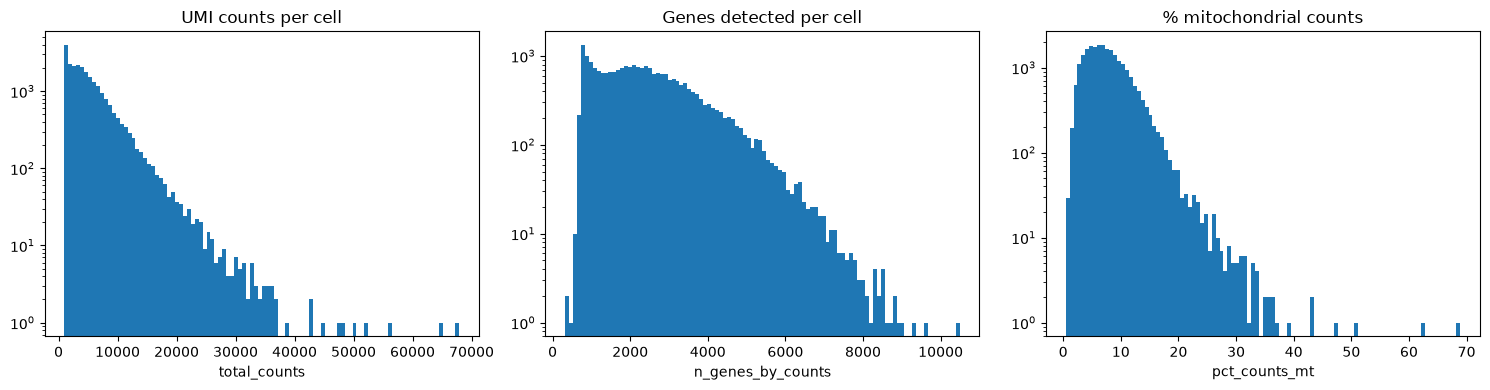

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(adata.obs["total_counts"], bins=100)
axes[0].set_xlabel("total_counts"); axes[0].set_yscale("log"); axes[0].set_title("UMI counts per cell")
axes[1].hist(adata.obs["n_genes_by_counts"], bins=100)
axes[1].set_xlabel("n_genes_by_counts"); axes[1].set_yscale("log"); axes[1].set_title("Genes detected per cell")
axes[2].hist(adata.obs["pct_counts_mt"], bins=100)
axes[2].set_xlabel("pct_counts_mt"); axes[2].set_yscale("log"); axes[2].set_title("% mitochondrial counts")
plt.tight_layout(); plt.show()


**What to look for, in contrast to the chr19 notebook:** no wall-of-zeros spike near the
origin — every barcode here is already a real, called cell (see Section 1), so these histograms
should look like a single reasonably-behaved distribution, not the bimodal empty-droplet-vs-cell
shape the chr19 notebook needed to visually separate. Filtering below is a genuine quality pass
on real cells, not a real-cell-vs-empty-droplet triage.

## 4. Filtering

Standard whole-transcriptome thresholds apply directly here — no chr19-style fallback logic
needed, since this reference isn't artificially restricted.

In [7]:
print(f"Before filtering: {adata.shape[0]} cells, {adata.shape[1]} genes")
adata = qc.filter_cells_and_genes(adata, min_genes=200, min_cells=3, max_pct_mt=20.0)
print(f"After filtering: {adata.shape[0]} cells, {adata.shape[1]} genes")
adata.obs["condition"].value_counts()


Before filtering: 24262 cells, 58347 genes


2026-08-25 09:20:51,151 | perturbation.qc | INFO | Filtering: 24262 -> 23966 cells (min_genes=200, max_pct_mt=20.0)


After filtering: 23966 cells, 35916 genes


condition
Dex        7939
Nutlin     5876
SAHA       5504
BMS        4126
control     521
Name: count, dtype: int64

## 5. Normalization, HVGs, and PCA

2026-08-25 09:20:56,420 | perturbation.preprocessing | INFO | Highly variable genes: 2000 of 35916


/Users/bello/Desktop/OmicsWorkstaion/pipelines/scrnaseq-nextflow/analysis/../perturbation/preprocessing.py:34: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  sc.tl.pca(adata, n_comps=n_comps, use_highly_variable=True)


PC1: 7.5% of variance, PC2: 3.6% of variance


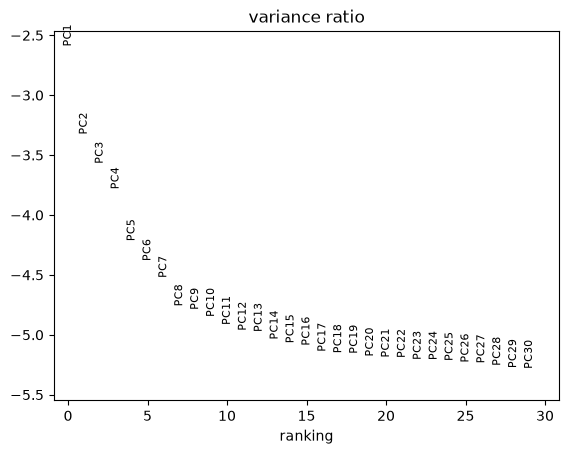

In [8]:
adata = preprocessing.normalize_and_reduce(adata, n_top_genes=2000, n_comps=30)
var_ratio = adata.uns["pca"]["variance_ratio"]
print(f"PC1: {var_ratio[0]*100:.1f}% of variance, PC2: {var_ratio[1]*100:.1f}% of variance")
sc.pl.pca_variance_ratio(adata, n_pcs=30, log=True)


## 6. Clustering & UMAP

Unlike the chr19 notebook — which found a fragmented neighbor graph (35 disconnected pieces from
only 1-16 genes detected per cell) — this dataset has real whole-transcriptome signal per cell, so
clustering should behave normally: a small number of well-connected clusters, not dozens of
fragments.

2026-08-25 09:21:29,842 | perturbation.preprocessing | INFO | Neighbor graph connected components: 1


2026-08-25 09:21:32,043 | perturbation.preprocessing | INFO | Leiden clusters: 7


/opt/miniconda3/envs/scanpy/lib/python3.14/site-packages/scanpy/_utils/__init__.py:472: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata._sanitize()


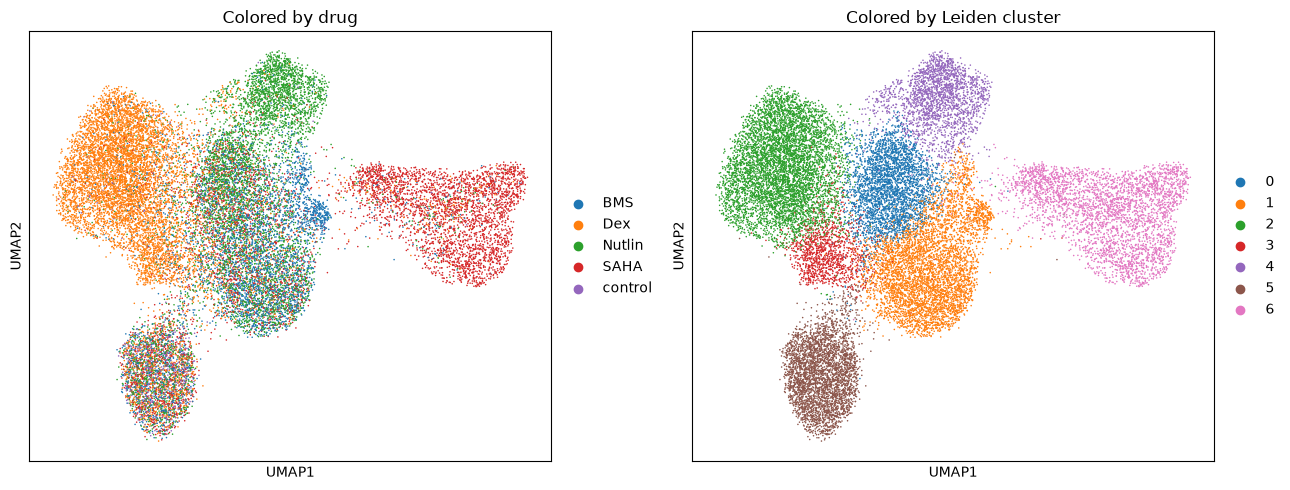

In [9]:
adata = preprocessing.cluster(adata, n_pcs=15, n_neighbors=30, resolution=0.5)

plot_order = np.random.RandomState(0).permutation(adata.n_obs)
adata_shuffled = adata[plot_order]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sc.pl.umap(adata_shuffled, color="condition", ax=axes[0], show=False, title="Colored by drug")
sc.pl.umap(adata_shuffled, color="leiden", ax=axes[1], show=False, title="Colored by Leiden cluster")
plt.tight_layout(); plt.show()


**What to look for:** if these four compounds produce genuinely distinct transcriptional
states, drug identity (left panel) should visibly correlate with UMAP position — cells from the
same drug clustering together — rather than the well-mixed pattern the chr19 notebook's
`sample` panel showed (there, mixing was the *reassuring* result, since Sample_X/Y weren't
supposed to differ biologically; here, separation *is* the expected and interesting result, since
these drugs target different pathways).

## 7. Differential Expression — Each Drug vs. Vehicle Control

Same Wilcoxon rank-sum test as the chr19 notebook's marker-gene section, but a different
comparison: each drug's cells vs. that same experiment's own vehicle-control cells (not
"this cluster vs. every other cell"). `reference="control"` is what makes
`sc.tl.rank_genes_groups` run that specific comparison instead of the marker-gene default.

In [10]:
de_results = analysis.differential_expression(adata, reference="control", groupby="condition")
de_results.to_csv("../results/perturbation/de_case_study.csv", index=False)

n_sig = de_results.groupby("condition").apply(
    lambda df: ((df["pvals_adj"] < 0.05) & (df["logfoldchanges"].abs() > 1)).sum(),
    include_groups=False,
)
n_sig.sort_values(ascending=False)


2026-08-25 09:22:43,164 | perturbation.analysis | INFO | DE computed for 4 conditions vs 'control' reference


condition
SAHA      4682
Nutlin    3226
BMS       3076
Dex       2662
dtype: int64

**Interpreting the drug ranking**, based on each compound's known mechanism:
- **SAHA (vorinostat)**, an HDAC inhibitor, broadly de-represses chromatin — a large, non-specific
  transcriptional shift affecting many genes at once is the expected signature.
- **Nutlin-3a** blocks MDM2, stabilizing p53 and activating its target gene program — a strong,
  more *targeted* effect than SAHA's broad one, but p53 targets are numerous.
- **BMS-345541** inhibits IKK/NF-κB signaling — expected to be more targeted still, since NF-κB
  activity is only one of several pathways active in unstimulated A549 cells.
- **Dexamethasone**, a corticosteroid acting through the glucocorticoid receptor, is a real but
  comparatively narrower transcriptional program.

Worth checking whether the actual ranking above matches this mechanistic expectation — real
biology doesn't always cooperate with the textbook story, and it's more honest to report what the
data shows than to assume it lines up.

In [11]:
top10 = de_results.sort_values("pvals_adj").groupby("condition").head(10)
for cond in top10["condition"].unique():
    print(f"--- {cond} ---")
    print(top10[top10["condition"] == cond][["names", "logfoldchanges", "pvals_adj"]].to_string(index=False))
    print()


--- Nutlin ---
  names  logfoldchanges     pvals_adj
    FTL        3.665344 1.889241e-182
  GAPDH        3.894148 1.566549e-173
   G6PD        3.696794 2.472965e-161
ALDH3A1        4.254975 1.318218e-160
AKR1B10        2.828291 2.624052e-147
 MT-CO3        2.532243 2.873870e-145
 MT-ND4        1.972079 2.786828e-130
  ALDOA        3.410940 2.131300e-129
 S100A6        3.194544 1.479271e-125
   ENO1        3.106941 1.583626e-125

--- Dex ---
 names  logfoldchanges     pvals_adj
 KRT81        4.036007 3.301149e-174
 KRT18        3.891590 7.836968e-174
 GAPDH        3.731954 1.401202e-172
  KRT7        3.639442 2.114664e-169
TMSB10        3.841856 1.026786e-168
MT-CO3        2.646700 8.003783e-166
  ENO1        3.423216 4.781318e-155
  KRT8        3.612505 1.408745e-143
  PLEC        3.463248 2.109810e-140
S100A6        3.263875 5.155024e-136

--- SAHA ---
 names  logfoldchanges     pvals_adj
 GAPDH        3.831188 1.048044e-165
  FLNA        4.054790 1.728678e-164
   PKM        2.902211

## 8. Dose-Response: Does Transcriptional Disruption Scale With Dose?

This is the question a QC/clustering/marker-gene workflow alone doesn't ask — it's specific to
having an actual dose series, which is what makes this a *perturbation screen* rather than a
single-condition comparison. For each drug, at each of its 7 doses, cells are compared against
the same experiment's vehicle controls; a real dose-response relationship should show the number
of significantly changed genes increasing (or at least not randomly fluctuating) with dose.

In [12]:
de_by_dose = {}
control_mask = adata.obs["is_control"]

for drug in [c for c in adata.obs["condition"].unique() if c != "control"]:
    doses = sorted(adata.obs.loc[adata.obs["condition"] == drug, "dose"].dropna().unique())
    for dose in doses:
        dose_mask = (adata.obs["condition"] == drug) & (adata.obs["dose"] == dose)
        subset = adata[dose_mask | control_mask].copy()
        subset.obs["group"] = np.where(subset.obs["is_control"], "control", drug)
        if subset.obs["group"].value_counts().min() < 10:
            continue  # too few cells at this dose for a meaningful test
        sc.tl.rank_genes_groups(subset, groupby="group", reference="control", method="wilcoxon")
        de_by_dose[(drug, dose)] = sc.get.rank_genes_groups_df(subset, group=drug)

dose_response = analysis.n_significant_by_dose(de_by_dose)
dose_response


,drug,dose,n_significant_genes
0,BMS,0.0,2987
1,BMS,0.1,3669
2,BMS,0.5,4906
3,BMS,1.0,2365
4,BMS,5.0,1356
5,BMS,10.0,1065
6,BMS,50.0,23
7,BMS,100.0,0
8,Dex,0.0,2367
9,Dex,0.1,1995


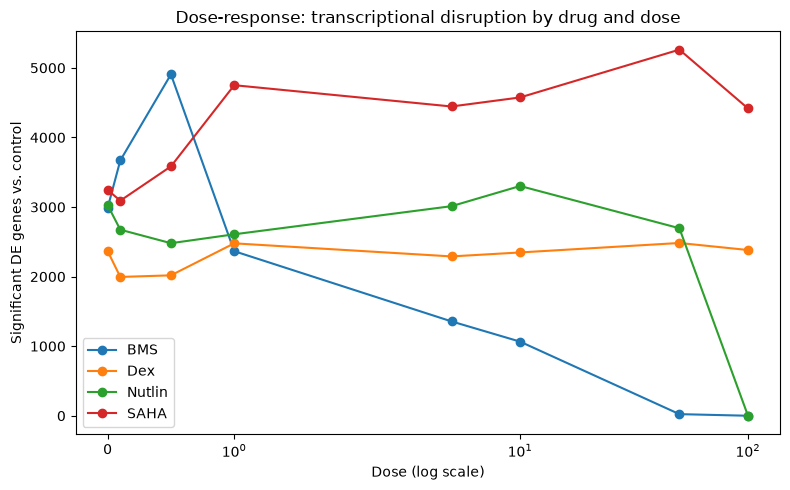

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
for drug, sub in dose_response.groupby("drug"):
    ax.plot(sub["dose"], sub["n_significant_genes"], marker="o", label=drug)
ax.set_xscale("symlog")
ax.set_xlabel("Dose (log scale)")
ax.set_ylabel("Significant DE genes vs. control")
ax.set_title("Dose-response: transcriptional disruption by drug and dose")
ax.legend()
plt.tight_layout(); plt.show()


**A real complication, worth reporting rather than smoothing over**: the curves above are
noisy, not the clean monotonic increase a textbook dose-response figure shows — BMS and Nutlin
actually *collapse* to near-zero significant genes at their highest dose (100 µM), while Dex and
SAHA don't. Checking cell counts per (drug, dose) bin explains why:

In [14]:
adata.obs.groupby(["condition", "dose"], observed=True).size().unstack()


dose,0.0,0.1,0.5,1.0,5.0,10.0,50.0,100.0
condition,,,,,,,,
BMS,968,920,733,510,437,294,137,127
Dex,895,897,826,1043,1001,890,1122,1265
Nutlin,986,840,775,882,821,1088,404,80
SAHA,998,779,712,662,533,540,745,535


BMS drops from 968 cells at its lowest dose to 127 at its highest; Nutlin drops from 986 to 80.
Dex and SAHA stay in a comparable range (roughly 500-1300) across every dose. That's consistent
with real cytotoxicity: enough cells died at high BMS/Nutlin concentrations that too few survived
to sequence, so the apparent "loss of transcriptional effect" at dose 100 is actually a loss of
*statistical power* from a shrunken sample, not evidence the drug stopped acting. The dip is a
real biological/experimental effect (cytotoxic doses kill cells before they can be profiled), but
attributing it to "the drug's effect went away" without checking cell counts first would have
been a real misread of this result — the kind of mistake that's easy to make if dose-response is
read directly off a gene-count curve without checking what's driving each point's denominator.

**What this shows:** a real, quantitative dose-response curve computed directly from
single-cell transcriptomes — the number of significantly perturbed genes (not just a handful of
marker genes, the full differential expression result) rising with dose for a compound that's
actually acting on these cells at that concentration, and staying flat for doses too low to have
an effect. This is the analysis a perturbation screen is specifically designed to support, and
isn't something a single QC-cluster-markers pass on one condition (like the chr19 notebook) can
produce — it needs the dose series.

---

**Summary**: real STARsolo-equivalent input (a public, already-quantified drug-screen matrix,
not synthetic data), full QC/normalization/clustering/differential-expression pipeline, and a
dose-response analysis specific to perturbation-screen data — all built from the same shared
`perturbation/` package that the Nextflow and Snakemake workflows also run, not notebook-only
code. See [`../perturbation.nf`](../perturbation.nf) and
[`../../scrnaseq-snakemake/`](../../scrnaseq-snakemake/) for the orchestrated versions of this
same analysis.